# 確率分布

## 使用するモジュールについて

このノートブックでは，次のモジュールを使用する。
* `scipy.stats`  （統計関係の関数）
* `matplotlib`   （グラフの描画）
* `numpy`        （ベクトル等の数値計算）
* `pandas`       （データフレーム）

Jupyter Notebook が動作する環境ではインストール済みのはずである。

上記モジュールを使ってデータを作成したりグラフを描いたりするため，このノートでは各セルを実行する前に次を実行することを前提とする。

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## scipy が提供する確率分布

`scipy` で確率分布を利用する方法は，主に次の2つに分けられる。
1. 確率分布サブモジュールのメソッドを利用する
2. 確率分布コンストラクタのメソッドを利用する

サブモジュール名とコンストラクタ名は同じである。

確率分布のサブモジュールを dist, そのメソッドを func とすると，前者は
```python
from scipy.stats import dist
y = dist.func(x, loc = μ, scale = σ)
```
のように使う。後者は
```python
from scipy.stats import dist
δ = dist(loc = μ, scale = σ)
y = δ.func(x)
```
のように使う。 δ はコンストラクタが生成した確率分布オブジェクトである。

簡便な用途には前者の使い方をする。
後者は，特定の確率分布を何度も利用したり，
パラメータ違いだけの確率分布を利用するとき便利である

確率密度関数 pdf や，累積分布関数 cdf は次のように使う。
```python
y = dist.pdf(x, loc = μ, scale = σ)

δ = dist(loc = μ, scale = σ)
y = δ.pdf(x)
```

変数 x にスカラー（浮動小数点数など）の値を与えることもあるが
実用的には，ベクトル（リストや `numpy` の配列）を与えることが多いだろう。
このノートブックでは，
ベクトルの変数を xs, ys のように，変数名の末尾に s を付けて，
スカラーの変数 x, y と区別するようにしている。
プログラムの<ruby>字面<rp> (</rp><rt>じづら</rt><rp>) </rp></ruby>を見るだけで
スカラーに対する処理をしているのか，
ベクトル（配列）に対する処理をしているのか，
瞬時に区別できるようにするためである。

### 主な離散確率分布

| コンストラクタ       | 摘要 |
|--------------------|-----|
| randint($a$, $b$) | 区間 $a\leqq X < b$ の離散一様分布|
| binom($n$, $p$)    | 試行数 $n$, 成功確率 $p$ の二項分布 |
| bernoulli($p$)      | 成功確率 $p$ ベルヌーイ分布（試行数1の二項分布）|
| poisson($\mu$)       | 平均値 $\mu$ のポアソン分布 |
| geom($p$)             | 成功確率 $p$ の幾何分布（成功するまでの試行回数）|
| hypergoem($M$, $n$, $N$) | 全体で $M$ 個のうち$n$個の当たりがあって$N$回選ぶ超幾何分布 |
| nbinom($n$, $p$)   | 成功確率 $p$ で $n$ 回成功するまでの失敗回数（負の二項分布）|
| zipf($\alpha$)     | ゼータ関数 $\zeta(\alpha)$ による Zipf分布 |

### 主な連続確率分布

| コンストラクタ           | 摘要 |
|-----------------------|-----------|
| uniform()             | $0 \leqq X < 1$ の一様分布 |
| triang($c$)           | $0 \leqq X < 1$ で頂点の位置が $c$ の三角分布 |
| normal()              | 標準正規分布（平均値 $\mu=0$, 分散 $\sigma^2=1$）|
| chi2($\nu$)           | 自由度 $\nu$ のカイ2乗分布 |
| t($\nu$)              | 自由度 $\nu$ のスチューデント t 分布 |
| f($\nu_1$, $\nu_2$)   | 自由度 $\nu_1$, $\nu_2$ の F分布 |
| cauchy()              | コーシー分布（自由度 1の t分布に同じ）|
| expon()               | 指数分布（平均値 $1/\lambda = 1$）|
| halfnormal()          | 標準正規分布の右半分 |
| lognormal($\sigma$)   | 標準偏差 $\sigma$ の対数正規分布 |
| laplace()             | ラプラス分布 |
| pareto($b$)           | パレート分布 |

### 分布に対するメソッド

| メソッド        | 摘要 |
|----------------|-----|
| mean()         | 期待値（平均値） |
| var()          | 分散 |
| std()          | 標準偏差 |
| stats()        | 期待値，分散，歪度，尖度 |
| moment()       | モーメント |
| pmf($x$)       | 確率質量関数 |
| pdf($x$)       | 確率密度関数 |
| cdf($x$)       | 累積分布関数 $\int_{-\infty}^x \mathrm{pdf}(t)\,dt$|
| sf($x$)        | 生存関数 (survival function) $1-\mathrm{cdf}(x) = \int_x^{\infty} \mathrm{pdf}(t)\,dt$ |
| ppf($p$)       | パーセント点（パーセンタイルの確率分布版，累積分布の逆関数）|
| isf($p$)       | 上側パーセント点 ppf($1-p$), 生存関数の逆関数 (inverse of sf) |
| rvs(size=$n$)  | 確率分布に従う乱数列 |

### 使用例1： 確率分布モジュールを使う

確率分布モジュールをインポートし，モジュールの関数を使用する。

<BarContainer object of 11 artists>

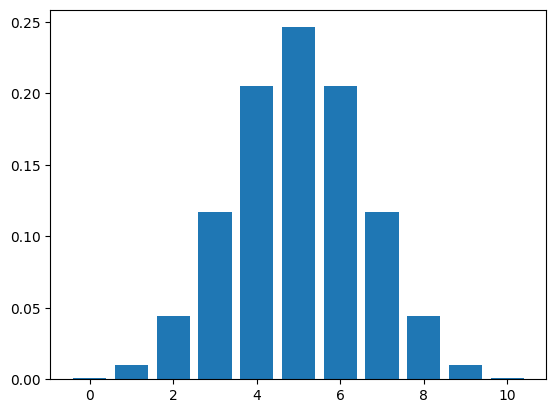

In [4]:
from scipy.stats import binom
import matplotlib.pyplot as plt

sample_size = 10
xs = range(0, sample_size + 1)
ys = [ binom.pmf(x, n = sample_size, p = 1/2) for x in xs ]
plt.bar(xs, ys)

### 使用例2： コンストラクタを使う

確率分布コンストラクタで確率分布オブジェクトを作り，
そのメソッド（関数）でグラフを描く。
同じパラメータの確率分布を使うときは便利である。

<BarContainer object of 11 artists>

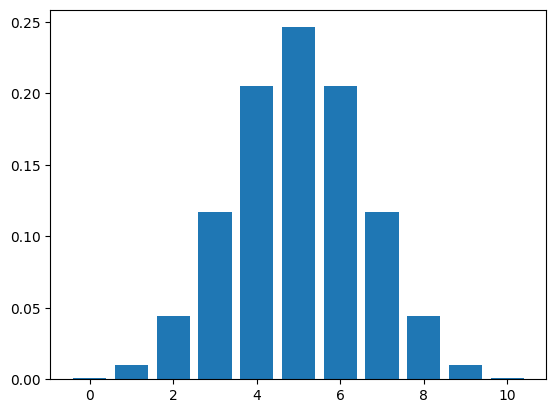

In [3]:
from scipy.stats import binom
import matplotlib.pyplot as plt

sample_size = 10
dist = stats.binom(n = sample_size, p = 1/2)
xs = range(0, sample_size + 1)
ys = [ dist.pmf(x) for x in xs ]
plt.bar(xs, ys)

`binom.stats` 関数で，二項分布の平均値，分散が得られる。
関数のキーワードパラメータとして `moments='mvsk'` も与えると，
平均値 (mean), 分散 (variance) だけでなく，
<ruby>歪度<rp>(</rp><rt>わいど</rt><rp>)</rp></ruby> (skewness),
<ruby>尖度<rp>(</rp><rt>せんど</rt><rp>)</rp></ruby> (kurtosis) が得られる。

In [42]:
from scipy.stats import binom

print(binom.stats(n=10, p=1/2))
print(binom(n=10, p=1/2).stats(moments='mvsk'))

(5.0, 2.5)
(5.0, 2.5, 0.0, -0.2)


## 確率分布の前提知識

次の事項は既知とする。

* 確率分布の基本概念
    * 確率変数
    * 期待値
    * 確率密度関数 (PDF), 累積分布関数 (CDF)
* 代表的な確率分布
    * 二項分布
    * 正規分布

## 二項分布　(binomial distribution)

### Python による二項分布の計算

`scipy.stats` の `binom` により二項分布の計算ができる。

次のセルは，
試行回数 $n = 2$, 成功確率 $p = 1/2$ の二項分布を計算する。
結果は，成功回数とその確率である。

In [2]:
from scipy.stats import binom
import pandas as pd

n = 2
p = 1/2
xs = range(n+1)
ys = binom.pmf(xs, n, p)

pd.DataFrame({'確率': ys})

,確率
0,0.25
1,0.50
2,0.25


次は $n = 3$, $p = 1/2$ の二項分布

In [33]:
from scipy.stats import binom
import pandas as pd

n = 3
p = 1/2
xs = range(n+1)
ys = binom.pmf(xs, n, p)

pd.DataFrame({'確率': ys})

,確率
0,0.125
1,0.375
2,0.375
3,0.125


次は $n = 4$, $p = 1/2$ の二項分布

In [34]:
from scipy.stats import binom
import pandas as pd

n = 4
p = 1/2
xs = range(n+1)
ys = binom.pmf(xs, n, p)
pd.DataFrame({'確率': ys})

,確率
0,0.0625
1,0.2500
2,0.3750
3,0.2500
4,0.0625


グラフを描いてみる。

<BarContainer object of 5 artists>

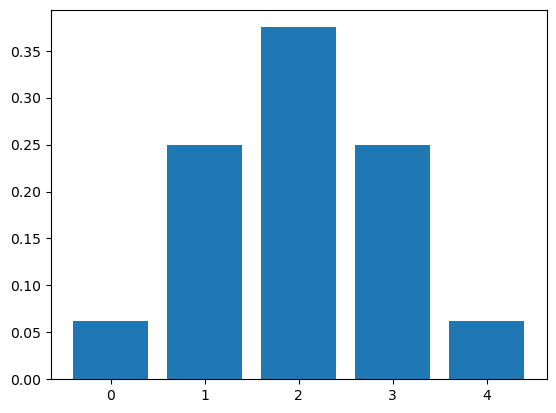

In [3]:
from scipy.stats import binom
import pandas as pd
import matplotlib.pyplot as plt

n = 4
p = 1/2
xs = range(n+1)
ys = binom.pmf(xs, n, p)
plt.bar(xs, ys)

<BarContainer object of 7 artists>

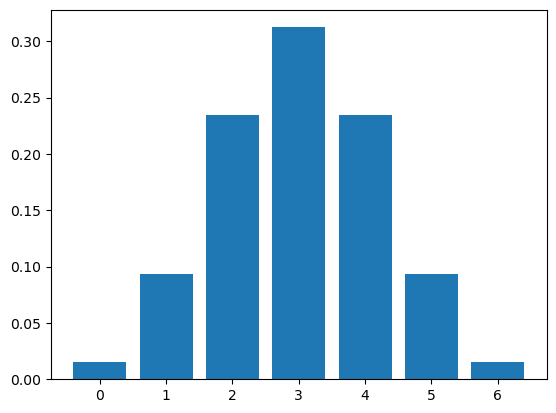

In [10]:
from scipy.stats import binom
import pandas as pd
import matplotlib.pyplot as plt

n = 6
θ = 1/2
xs = range(n+1)
dist = binom(n, θ)
ys = dist.pmf(xs)
plt.bar(xs, ys)

コードが長くなってきたので，次に定義する関数を使って簡便に実行する。
次のセルを実行しておかないと，本節の残りのセルは実行できない。

In [33]:
from scipy.stats import binom
import pandas as pd
import matplotlib.pyplot as plt

def binomTable(n, θ=1/2):
    xs = range(n+1)
    dist = binom(n, θ)
    ys = dist.pmf(xs)
    return pd.DataFrame({'確率': ys})

def binomPlot(n, θ=1/2):
    xs = range(n+1)
    dist = binom(n, θ)
    ys = dist.pmf(xs)
    plt.bar(xs, ys)

In [2]:
binomTable(10)

,確率
0,0.000977
1,0.009766
2,0.043945
3,0.117188
4,0.205078
5,0.246094
6,0.205078
7,0.117187
8,0.043945
9,0.009766


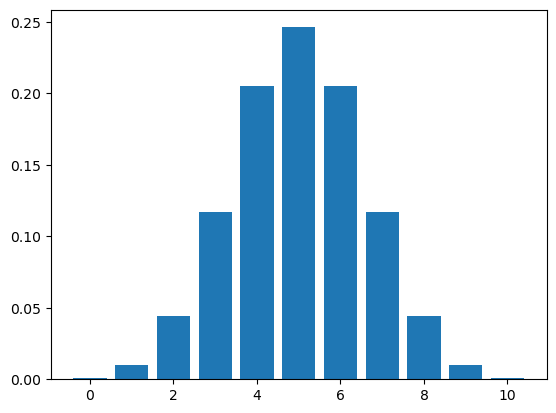

In [3]:
binomPlot(10)

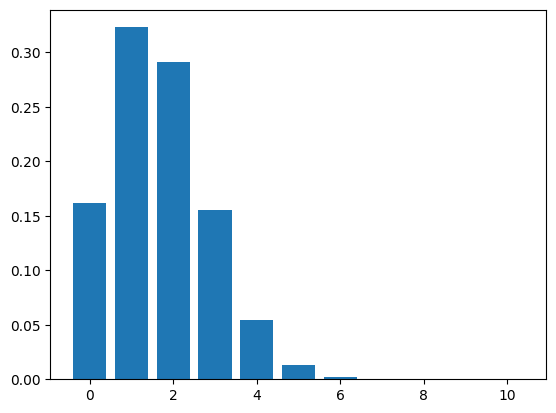

In [48]:
binomPlot(10, 1/6)

### 期待値など

証明しないが，
確率変数 $X$ が，試行数 $n$, 成功確率 $p$, 失敗確率 $q = 1 - p$ の二項分布に従うとき，
$X$ の期待値は
$$
E(X) = np
$$

$X$ の分散は
$$
V(X) = npq
$$
である。

## ポアソン分布

ポアソン分布 (Poisson Distribution) とは，小さな確率の現象が無数に生じる結果として観察される確率分布である。

たとえばA県では1年間に100名の人が交通事故で死亡するとする。死亡事故は3日に1度，均等に発生するわけでなく，何日も事故が発生しなかったと思うと，1日に2名3名と死亡することもある。もともとは，ド・モアブルが不当判決の発生件数を考察するために編み出したものである。その後，1年間に馬に蹴られて死亡する騎馬兵の数のモデル化などに使用された。保険会社が，保険金の支払いが重なるリスクがどれだけあるかを見積もるモデルにもなる。

### 参考：二項分布との関係

試行回数 $n$, 成功確率 $p$ の二項分布の確率質量関数 $\mathrm{pmf}(X)$ は
$$
\mathrm{pmf}(X)= {}_{n}\mathrm{C}_{X} \cdot p^X\cdot (1-p)^{n-X}
$$
である。これを $\mu=np$ という制約のもとで
$n\to\infty$ とするとポアソン分布が得られる。
すなわち

$$
\mathrm{Poi}(\mu) := \lim_{n\to\infty} B\left(n, \frac{\mu}{n}\right)
$$

平均値 $\mu$ のポアソン分布の確率質量関数は，
スターリングの公式（階乗の近似公式）により
$$
\mathrm{pmf}(X) = \frac{\mu^X\exp(-\mu)}{X!}
$$

`scipy.stats` モジュールのポアソン分布は次のように使う。

In [23]:
from scipy.stats import poisson

μ = 0.5

dist = poisson(μ)        # 平均値 μ のポアソン分布オブジェクト
dist = poisson(mu = μ)   # 平均値をキーワード・パラメータ mu で明示してもよい

# 確率密度関数を f(x) で得るには
f = lambda x: dist.pmf(x)            # 確率分布オブジェクト dist から
f = lambda x: poisson.pmf(x, mu = μ) # 平均値パラメータを与えれば直接書くのも可能

A県の交通事故による死亡件数について，ポアソン分布でシミュレーションを行いたい。

In [20]:
from scipy.stats import poisson
import pandas as pd

μ = 0.5
dist = poisson(μ)
xs = range(5)
ys = dist.pmf(xs)
pd.DataFrame({'割合': ys})

,割合
0,0.606531
1,0.303265
2,0.075816
3,0.012636
4,0.001580


グラフを描いてみる。

<BarContainer object of 5 artists>

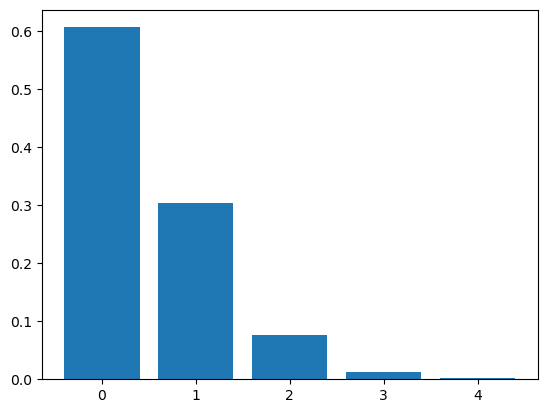

In [25]:
from scipy.stats import poisson
import matplotlib.pyplot as plt

μ = 0.5
dist = poisson(μ)
xs = range(5)
ys = dist.pmf(xs)
plt.bar(xs, ys)

ポアソン分布は二項分布の極限とのことなので，
$n$ を大きくし，それに合わせて $p$ を小さくすれば，
二項分布でも同様の結果が得られるはずだ。
試しに $n$ を A県の人口 1,000,000人，
$p$ を県民1人1人が1日に交通事故で死亡する確率 $\frac{0.5}{n}$ としよう。

In [22]:
binomTable(1_000_000, 0.5 / 1_000_000).head(5)

,確率
0,0.606531
1,0.303265
2,0.075816
3,0.012636
4,0.001580


この範囲では，ポアソン分布と同じ結果が得られた。
それより先は，微小なので無視してよいだろう。

以下では，ポアソン分布のグラフ（確率質量関数）を見ていく。

<BarContainer object of 6 artists>

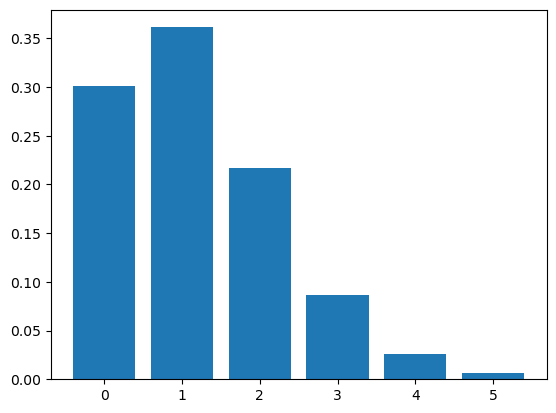

In [28]:
from scipy.stats import poisson
import matplotlib.pyplot as plt

μ = 1.2
n = 5
xs = range(n+1)
ys = poisson.pmf(xs, mu = μ)
plt.bar(xs, ys)

峰 (peak) が $X = 1$ に移った。

<BarContainer object of 9 artists>

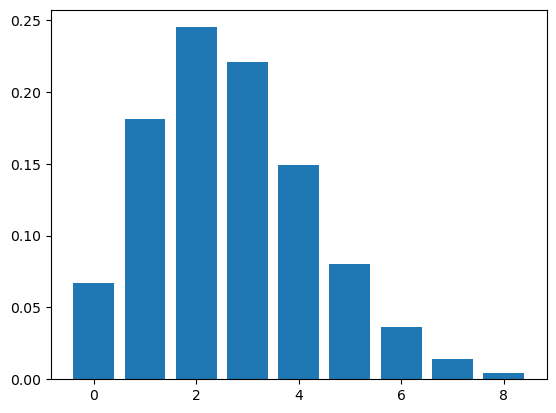

In [30]:
from scipy.stats import poisson
import matplotlib.pyplot as plt

μ = 2.7
n = 8
xs = range(n+1)
ys = poisson.pmf(xs, mu = μ)
plt.bar(xs, ys)

平均値 $\mu$ が大きくなると正規分布に近づく
（左右対称になってくる）。

<BarContainer object of 21 artists>

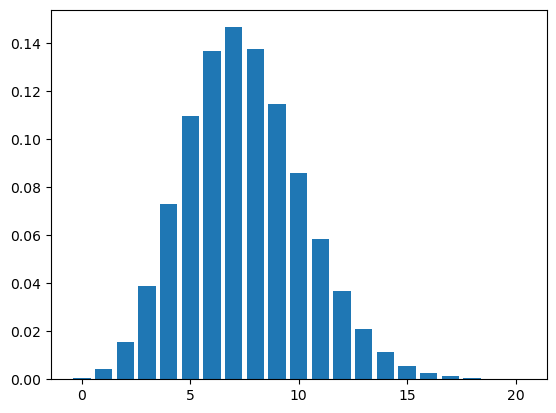

In [31]:
from scipy.stats import poisson
import matplotlib.pyplot as plt

μ = 7.5
n = 20
xs = range(n+1)
ys = poisson.pmf(xs, mu = μ)
plt.bar(xs, ys)

## 幾何分布

幾何分布とは，
成功確率 $p$ のベルヌーイ試行が成功するまでの回数の確率分布である。
たとえば

* コイントスで言えば，最初に表（おもて）になるまでコインを何回投げるか
* ボウリングあるいは野球の投球で言えば，確率 $p$ でストライクを取れる人が，最初にストライクをとれるまでの回数

### 確率質量関数

**幾何分布**の名称は，確率質量関数が等比数列＝幾何数列，
累積分布関数が等比級数＝幾何級数になることに由来する。
確率質量関数は次のとおり
$$
\mathrm{pmf}(X) = (1-p)^{X-1} p.
$$

指数の肩の $X-1$ を $X$ にした $(1-p)^X p$ だと，
成功するまでの失敗回数になる。
この方が式が簡単になるのでテキストによってはこちらを採用している。

しかし Python の `scipy.stat.geom` は，成功するまでの試行回数
という定義を採用している。
そのため 試行回数は必ず 1以上になる。
$\therefore\; \Pr(X = 0) = 0.$

なお成功確率 $p$ は確率分布のパラメータなので，確率変数 $X$ にとっては定数である。
つまり確率質量関数 $\mathrm{pmf}(X)$ は $X$ の冪乗関数である。
また $X$ は正の整数の値しかとらない ($X = 1, 2, 3, \ldots$) ので
等比数列である。等比数列は**幾何数列** (geometric sequence) ともいう。

In [39]:
from scipy.stats import geom
import pandas as pd

p = 0.5
dist = geom(p)
xs = range(0, 10)
ys = dist.pmf(xs)
pd.DataFrame({'割合': ys})

,割合
0,0.000000
1,0.500000
2,0.250000
3,0.125000
4,0.062500
5,0.031250
6,0.015625
7,0.007812
8,0.003906
9,0.001953


<BarContainer object of 10 artists>

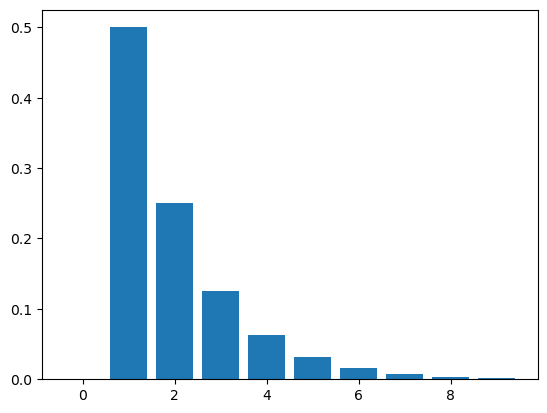

In [40]:
import matplotlib.pyplot as plt

plt.bar(xs, ys)

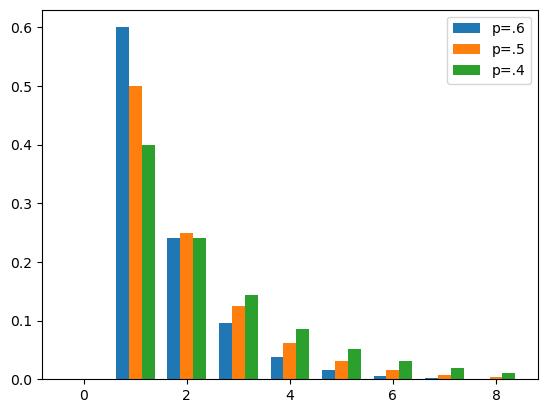

In [60]:
from scipy.stats import geom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

xs = np.arange(0, 9)

ys6 = geom.pmf(xs, 0.6)
plt.bar(xs-0.25, ys6, width=0.25)

ys5 = geom.pmf(xs, 0.5)
plt.bar(xs, ys5, width=0.25)

ys4 = geom.pmf(xs, 0.4)
plt.bar(xs+0.25, ys4, width=0.25)

plt.legend(["p=.6", "p=.5", "p=.4"])

### 幾何分布のモーメント（期待値など）

幾何分布 $G(p)$ の
平均値（期待値），分散，歪度，尖度は，それぞれ次のとおり。
ただし $q = 1-p$ つまり失敗確率とする。

$$
\begin{align}
E(X) &= 1/p \\
\mathrm{Var}(X) &= \frac{1-p}{p^2} = \frac{q}{p^2} \\
\mathrm{Skew}(X) &= \sqrt{1-p} + \frac{1}{\sqrt{1-p}} = \sqrt{q} + \frac{1}{q} \\
\mathrm{Kurt}(X) &= \frac{p^2-6p+6}{1-p} = 4 + q + \frac{1}{q}
\end{align}
$$

## 指数分布

幾何分布の連続版が指数分布である。

パラメータ $\lambda$ の指数分布を $\mathrm{Exp(\lambda)}$ と表記することにする。

### パラメータと期待値

パラメータ <ruby>&lambda;<rp>（</rp><rt>ラムダ</rt><rp>）</rp></ruby> の
意味は期待値等を見るとわかる。
次は，期待値，分散，歪度，尖度である。
$$
\begin{align}
E(X) &= \frac{1}{\lambda} \\
\mathrm{Var}(X) &= \frac{1}{\lambda} \\
\mathrm{Skew}(X) &= 2 \\
\mathrm{Kurt}(X) &= 6 \\
\end{align}
$$

左右対称な分布の歪度は 0である。2は，大きく左に偏っていることを意味する。
尖度は分布の裾の重さを表していて， 6というのは，他では見ない大きさである。

### 確率密度関数
$$
\mathrm{pdf}(x) = \lambda\exp(-\lambda x)
$$

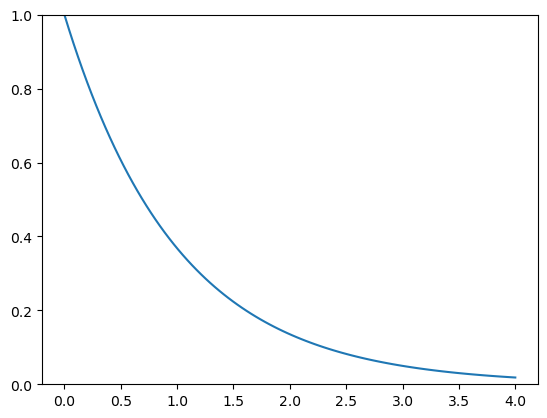

In [10]:
from scipy.stats import expon
import numpy as np
import matplotlib.pyplot as plt

λ = 1.0
dist = expon(scale = λ)
xs = np.linspace(0, 4, 100)
ys = dist.pdf(xs)
plt.ylim(0.0, 1.0)
plt.plot(xs, ys)

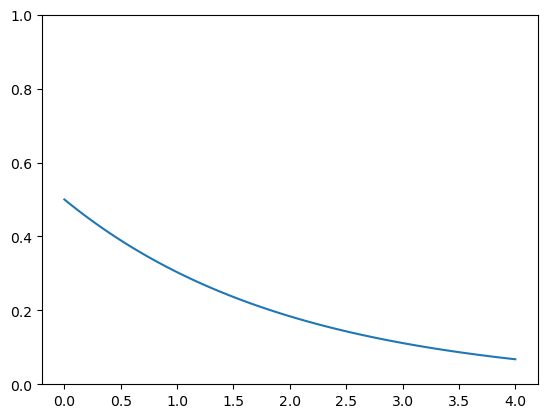

In [9]:
λ = 2.0
ys = expon.pdf(xs, scale = λ)
plt.ylim(0.0, 1.0)
plt.plot(xs, ys)

### 累積分布関数と生存関数

確率密度関数 (pdf) を定積分すると累積分布関数 (cdf) になる。

$$
\mathrm{cdf}(x) = 1 - \exp(-\lambda x)
$$

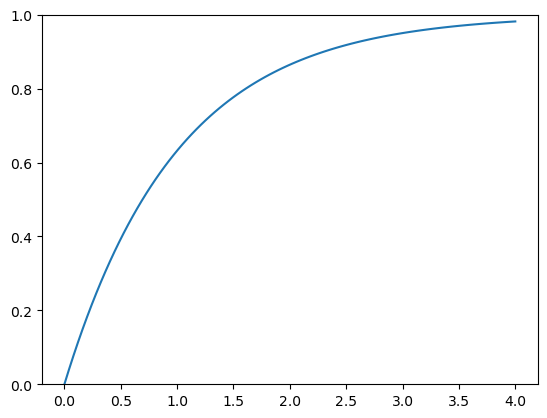

In [11]:
ys = dist.cdf(xs)
plt.ylim(0.0, 1.0)
plt.plot(xs, ys)

生存関数は

$$
\mathrm{sf}(x) = 1 - \mathrm{cdf}(x) = \exp(-\lambda x)
$$

$a = e^\lambda$ となるように $a$ を定めれば

$$
\mathrm{sf}(x) = a^{-x}
$$

逆に言うと，指数分布とは生存関数が $a^{-x}$ である確率分布である。

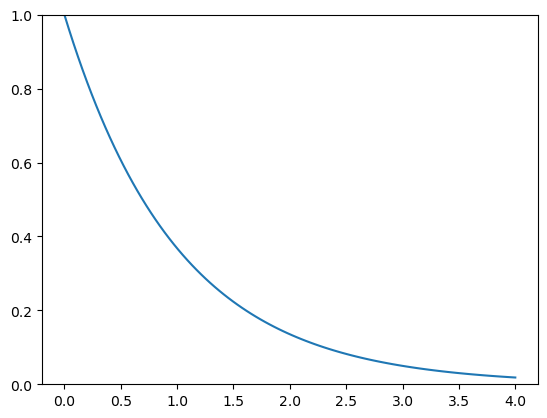

In [12]:
ys = dist.sf(xs)
plt.ylim(0.0, 1.0)
plt.plot(xs, ys)

## 負の二項分布

成功確率 $p$ のベルヌーイ試行を $n$ 回成功するまでに
失敗した回数の分布を負の二項分布という。

失敗回数 $X$ に対し $Y = X + 1$ とすると $Y$ は成功するまでの試行回数なので，
$n = 1$ のとき $Y$ の分布は**幾何分布**である。
つまり，幾何分布は負の二項分布の特別な例である。

負の二項分布の名称は，
確率質量関数が**負の二項係数**になることに由来する。
コイントスの確率分布とはおよそ関係ないので混乱しないでもらいたい。
二項係数との関係はいったん無視して，どういう分布になるか見ていく。

In [113]:
from scipy.stats import nbinom
import pandas as pd

p = 0.5
n = 3
dist = nbinom(n, p)
xs = range(15)
ys = dist.pmf(xs)
pd.DataFrame({'割合': ys})

,割合
0,0.125000
1,0.187500
2,0.187500
3,0.156250
4,0.117188
5,0.082031
6,0.054688
7,0.035156
8,0.021973
9,0.013428


<BarContainer object of 15 artists>

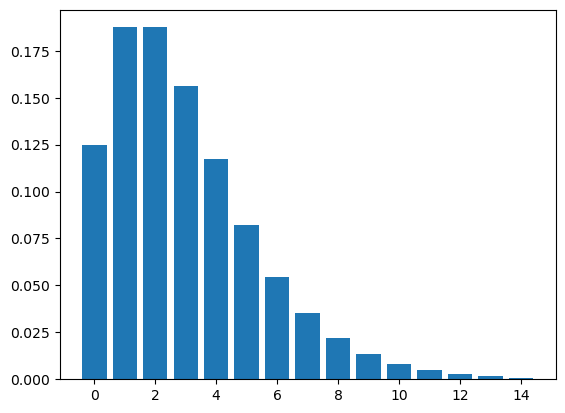

In [114]:
import matplotlib.pyplot as plt

plt.bar(xs, ys)

負の二項分布に関しては

* 何回で定着するか
* 何回で合格するか

が関心事であることが多いだろう。
これは累積分布関数で得られる。

In [117]:
ys = dist.cdf(xs)
pd.DataFrame({'割合': ys})

,割合
0,0.125000
1,0.312500
2,0.500000
3,0.656250
4,0.773438
5,0.855469
6,0.910156
7,0.945312
8,0.967285
9,0.980713


累積分布関数から次のことが読み取れる。
* $X=2$ で 50%; 失敗回数 2, 成功回数 _n_ = 3, 計試行回数5回で 50% の定着
* $X=7$ で 95%; 失敗回数 7, 成功回数 _n_ = 3, 計試行回数 10回で 95% の定着

<BarContainer object of 15 artists>

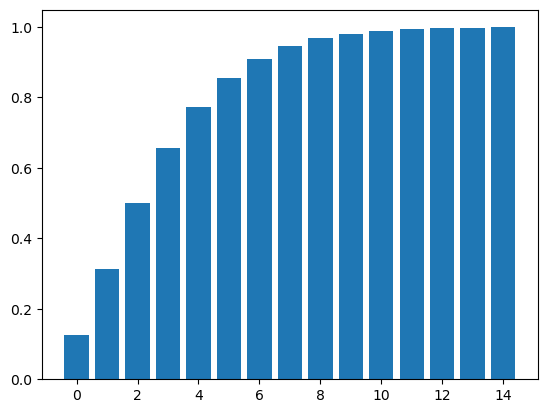

In [116]:
import matplotlib.pyplot as plt

plt.bar(xs, ys)

### 確率質量関数の導出

$n$ 回成功するまでに $k$ 回失敗する事象について調べる。
具体的に「3回成功するまでに2回失敗する」組合せを列挙する。
`O` を成功，`X` を失敗とする。

| 事象 |
|-----|
|XXOOO|
|XOXOO|
|XOOXO|
|OXXOO|
|OXOXO|
|OOXXO|

5回目の試行では必ず成功するので，
* 4回の試行で2回成功する組合せ
* （同じことだが）4回の試行で2回失敗する組合せ

を考えればよい。その組合せの個数は
$$
{}_4\mathrm{C}_2 = \frac{4!}{2!\cdot 2!} = 6
$$
である。

一般化する。次の組合せ（事象）は同一である。
* $n$ 回成功するまでに $k$ 回失敗
* $k + n$ 回試行し，$k$ 回失敗，最後の1回は成功
* $k + n - 1$ 回試行し $k$ 回失敗
* $k + n - 1$ 回試行し $n-1$ 回成功

組合せの個数は
$$
{}_{k + n - 1}\mathrm{C}_k = {}_{k + n - 1}\mathrm{C}_{n-1} =
    \frac{(k+n-1)!}{k!\cdot (n-1)!}
$$

成功確率 $p$, 失敗確率 $q = 1-p$ で，
$n$ 回成功する負の二項分布の確率変数 $K$ の確率密度関数は，
$K$ 回失敗する確率であり

$$
f(K) = p^n q^K \frac{(K + n  - 1)!}{K!\cdot(n-1)!}
$$

### SymPy の利用

負の二項係数について知るため SymPy を使いたい。

`math` モジュールの `comb` 関数を使うと二項係数を計算できるのだが，
この関数は負の数に対応していない（負の数を与えるとエラーになる）。
SymPy という記号計算 (symbolic computation) のモジュールに
`binomial` という二項係数を計算する関数があり，これが負の数に対応している。

日常的に Python を使っている利用者には
「SymPy をインストールせよ」の一言で解決する問題だが，
そうでないと何をしたらよいかわからないし，
さらには「落とし穴」まであるせいで，
一概にこうせよと指示することができない。
少々長くなるが，モジュールのインストール方法を述べる。

なおインストールしないという選択肢もある。
このノートブックで SymPy を使うのは，
次のセクションだけである。
**負の二項分布**自体は `scipy.stats.nbinom` にあり SymPy を必要としない。
セルの先頭に

```jupyter
import sympy
```

とか

```jupyter
from sympy import ...
```

と書かれているセルをスキップすれば，
SymPy をインストールしなくてもこのノートブックを使える。

ではモジュールのインストールに方法を説明する。
まず，使用している Python が
`PIP` と `conda` のどちらのパッケージ・システムで
管理されているかを把握する必要がある。
`conda` がインストールされていれば `conda` で管理しているだろうし，
インストールされていなければ `PIP` で管理しているであろう。
Jupyter の「ターミナル」を開いて次を実行する。

```sh
conda list
```

あるいは Jupyter のセルで次を実行する。

```ipython
%conda list
```

`conda` がインストールされていれば，インストール済みモジュール一覧が表示される。
なお `conda` で管理していても `PIP` でのインストールは可能で，
`conda` で提供していないモジュールをインストールするのに `PIP` を使うことがある。
しかし一般には，両者を混ぜて使うと，管理しているバージョン番号に不整合が生じて，
後々問題が起きる可能性が高い。一方でだけ使うべきである。

In [ ]:
%conda list

つづいて SymPy をインストールする。

`conda` でパッケージ管理されているなら
Jupyter のターミナルで次を実行する。

```sh
conda install sympy
```

ターミナルの開き方がわからなければ Jupyter のセルで次を実行する。
```jupyter
%conda install sympy
```

一方 `PIP` で管理しているならターミナルで次を実行する。
```sh
python -m pip upgrade pip
python -m pip install sympy
```

日常的に Python を使っていれば，
`python -m pip` の部分を `pip` で置き換えてよいだとか，
いや `pip3` にするだとか，
Jupyter のセル内で `%pip install sympy` でもできるだとか知っているだろう。
自己責任でやってかまわない（落とし穴はあるのであくまでも自己責任で）。

### 二項係数から負の二項係数へ

`math` モジュールの `comb` 関数を使うと
二項係数を計算できる。
ここからパスカルの三角形を作れる。

In [62]:
from math import comb

for n in range(10):
    print([ comb(n, k) for k in range(0, n+1) ])

[1]
[1, 1]
[1, 2, 1]
[1, 3, 3, 1]
[1, 4, 6, 4, 1]
[1, 5, 10, 10, 5, 1]
[1, 6, 15, 20, 15, 6, 1]
[1, 7, 21, 35, 35, 21, 7, 1]
[1, 8, 28, 56, 70, 56, 28, 8, 1]
[1, 9, 36, 84, 126, 126, 84, 36, 9, 1]


中央寄せ (centering) した方が見やすいかもしれない。
二項係数は，左上と右上を加算した値になっていることが確認できる。

In [64]:
from math import comb

for n in range(10):
    print(str([ comb(n, k) for k in range(0, n+1) ]).center(50))

                       [1]                        
                      [1, 1]                      
                    [1, 2, 1]                     
                   [1, 3, 3, 1]                   
                 [1, 4, 6, 4, 1]                  
               [1, 5, 10, 10, 5, 1]               
             [1, 6, 15, 20, 15, 6, 1]             
           [1, 7, 21, 35, 35, 21, 7, 1]           
         [1, 8, 28, 56, 70, 56, 28, 8, 1]         
      [1, 9, 36, 84, 126, 126, 84, 36, 9, 1]      


$k > n$ のとき ${}_n\mathrm{C}_k　= 0$ である

In [67]:
from math import comb

for n in range(10):
    print([ comb(n, k) for k in range(0, 11) ])

[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 3, 3, 1, 0, 0, 0, 0, 0, 0, 0]
[1, 4, 6, 4, 1, 0, 0, 0, 0, 0, 0]
[1, 5, 10, 10, 5, 1, 0, 0, 0, 0, 0]
[1, 6, 15, 20, 15, 6, 1, 0, 0, 0, 0]
[1, 7, 21, 35, 35, 21, 7, 1, 0, 0, 0]
[1, 8, 28, 56, 70, 56, 28, 8, 1, 0, 0]
[1, 9, 36, 84, 126, 126, 84, 36, 9, 1, 0]


これについても，左上と真上を加算することで
二項係数が得られることが確認できる。

これを $n < 0$ にも拡張するというのが
これからやりたいことである。

`sympy.binomial` を使うと $n < 0$ や $k < 0$ も含めて二項係数を計算できる。
まず $n \geq 0$ だが $k < 0$ のときどうなるか試してみる。

In [94]:
from sympy import binomial

for n in range(10):
    print([ binomial(n, k) for k in range(-2, 10) ])

[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 3, 3, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 4, 6, 4, 1, 0, 0, 0, 0, 0]
[0, 0, 1, 5, 10, 10, 5, 1, 0, 0, 0, 0]
[0, 0, 1, 6, 15, 20, 15, 6, 1, 0, 0, 0]
[0, 0, 1, 7, 21, 35, 35, 21, 7, 1, 0, 0]
[0, 0, 1, 8, 28, 56, 70, 56, 28, 8, 1, 0]
[0, 0, 1, 9, 36, 84, 126, 126, 84, 36, 9, 1]


確かに，左上と真上を加算した値になっている。

続いて $n < 0$ も調べてみる。

In [95]:
from sympy import binomial
# from sympy import symbols, var

for n in range(-9, 10):
    print([ binomial(n, k) for k in range(-2, 10) ])

[0, 0, 1, -9, 45, -165, 495, -1287, 3003, -6435, 12870, -24310]
[0, 0, 1, -8, 36, -120, 330, -792, 1716, -3432, 6435, -11440]
[0, 0, 1, -7, 28, -84, 210, -462, 924, -1716, 3003, -5005]
[0, 0, 1, -6, 21, -56, 126, -252, 462, -792, 1287, -2002]
[0, 0, 1, -5, 15, -35, 70, -126, 210, -330, 495, -715]
[0, 0, 1, -4, 10, -20, 35, -56, 84, -120, 165, -220]
[0, 0, 1, -3, 6, -10, 15, -21, 28, -36, 45, -55]
[0, 0, 1, -2, 3, -4, 5, -6, 7, -8, 9, -10]
[0, 0, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1]
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 3, 3, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 4, 6, 4, 1, 0, 0, 0, 0, 0]
[0, 0, 1, 5, 10, 10, 5, 1, 0, 0, 0, 0]
[0, 0, 1, 6, 15, 20, 15, 6, 1, 0, 0, 0]
[0, 0, 1, 7, 21, 35, 35, 21, 7, 1, 0, 0]
[0, 0, 1, 8, 28, 56, 70, 56, 28, 8, 1, 0]
[0, 0, 1, 9, 36, 84, 126, 126, 84, 36, 9, 1]


左上と真上を加算した値になっていることを確認してもらいたい。

$n < 0$ のときの二項係数は次の計算を行なっている。

$m = -n$ とすると
$$
(-1)^k\binom{-m}{k} = 
  \left|\binom{-m}{k}\right| = 
  {}_m\mathrm{H}_k =
  \binom{k + m - 1}{m - 1} =
  \binom{k + m - 1}{k}
$$

${}_m\mathrm{H}_k$ は**重複組合せ**（後述）の数で，
$m$ 種類から重複を許して $k$ 個選ぶ組み合わせの数を表す。

${}_m\mathrm{H}_k = \displaystyle\binom{k + m - 1}{k}$  を
`math.comb` で計算して確かめる。

In [119]:
from math import comb

for m in range(1, 10):
    print([ comb(k + m - 1, k) for k in range(10) ])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[1, 3, 6, 10, 15, 21, 28, 36, 45, 55]
[1, 4, 10, 20, 35, 56, 84, 120, 165, 220]
[1, 5, 15, 35, 70, 126, 210, 330, 495, 715]
[1, 6, 21, 56, 126, 252, 462, 792, 1287, 2002]
[1, 7, 28, 84, 210, 462, 924, 1716, 3003, 5005]
[1, 8, 36, 120, 330, 792, 1716, 3432, 6435, 11440]
[1, 9, 45, 165, 495, 1287, 3003, 6435, 12870, 24310]


### 重複組合せとは

例題：
赤，白，黒の3種類の玉が抽選箱に入っているとき
4個取り出すときの組み合わせの数はいくらか。

解答：赤，白，黒の順になるようにソーティングして列挙する。

| 玉の組み合わせ | 仕切りの位置 |
|----------|------------|
| 赤赤赤赤 | `....++` |
| 赤赤赤白 | `...+.+` |
| 赤赤赤黒 | `...++.` |
| 赤赤白白 | `..+..+` |
| 赤赤白黒 | `..+.+.` |
| 赤赤黒黒 | `..++..` |
| 赤白白白 | `.+...+` |
| 赤白白黒 | `.+..+.` |
| 赤白黒黒 | `.+.+..` |
| 赤黒黒黒 | `.++...` |
| 白白白白 | `+....+` |
| 白白白黒 | `+...+.` |
| 白白黒黒 | `+..+..` |
| 白黒黒黒 | `+.+...` |
| 黒黒黒黒 | `++....` |

このように玉の組み合わせは 15通りある。
これは玉と仕切りを併せたもの（6個）から仕切りを2個選ぶ組合せと同じである。

$$
{}_3\mathrm{H}_4 = {}_6\mathrm{C}_2 = \frac{6!}{4!\cdot 2!} = \frac{6\cdot 5}{2} = 15
$$

一般化すると，
> $n$ 種類の玉から $k$ 個選ぶときの重複組合せ

は，玉が $k$ 個，仕切りが $n-1$ 個のとき，

> 玉と仕切りを併せたもの $k + n - 1$ 個から，仕切り $n-1$ 個を選ぶ，
> あるいは玉 $k$ 個を選ぶ組合せ

と対応する。その個数は

$$
{}_n\mathrm{H}_k = {}_{k + n - 1}\mathrm{C}_{n - 1}
$$

負の二項分布の定義まで振り返ろう。
これは $n$ 回成功するまでに $k$ 回失敗する組合せの個数に等しい。

## 超幾何分布

**超幾何分布** (hypergeometric distribution)は
二項分布の非復元抽出バージョンである。

復元抽出では，抽選箱から取り出した玉は抽選箱に戻して，それから次の試行を行う。
すべての試行で成功確率は同一である。

非復元抽出では，抽選箱から取り出した玉を抽選箱に戻さずに次の試行を行う。
そのため
* 試行が成功すれば，当たりの球が減るので次の試行の成功確率が減る。
* 試行が失敗すれば，当たりの球が減らずに全体の球が減るので成功確率が高くなる。

超幾何分布は次のパラメータで定まる。

* 全体の個数 $M$
* 当たりの個数 $n$
* 試行回数 $N$

確率変数は，当たりが選ばれた個数である。

たとえばロシアンルーレットは，
全体の個数 $M=6$, 当たりの個数 $n = 1$ の超幾何分布とみなせる。
試行回数 $N=6$ とすると

確率変数 $K=0$ となる確率は

$$
\frac{5}{6}\cdot\frac{4}{5}
           \cdot\frac{3}{4}
           \cdot\frac{2}{3}
           \cdot\frac{1}{2}
           \cdot\frac{0}{1} = 0
$$

である。 $K=1$ となる確率は

$$
\frac{1}{6}+\frac{5}{6}\cdot\frac{1}{5}
           +\frac{5}{6}\cdot\frac{4}{5}\cdot\frac{1}{4}
           +\cdots
           +\frac{5}{6}\cdots\frac{1}{2}\cdot\frac{1}{1}
           = 1
$$

In [137]:
from scipy.stats import hypergeom
import pandas as pd

trials = 6
dist = hypergeom(6, 1, trials)
xs = range(2)
ys = dist.pmf(xs)
pd.DataFrame({'割合': ys})

,割合
0,0.0
1,1.0


このように，事象ごとに確率を計算すると，
試行するごとに玉の数が減り，
分母が ${}_n\mathrm{P}_r$ で表される式になる。
この式が**超幾何数列**と呼ばれるものに分類されることから，
この確率分布は**超幾何分布**と呼ばれている。
幾何分布とは名前が似ていても関係ない。

超幾何数列の定義に踏み込むと大変なので，基本イメージを紹介する。
無限級数とかテーラー展開を知っていることが前提である。

三角関数，指数関数を無限級数展開すると係数の分母に階乗が現れる。
他の関数でも，しばしば係数の分母，分子に，階乗や階乗を拡張したような式が現れる。
このような級数を，（等比級数＝幾何級数よりも複雑だという意味で）超幾何級数と
名前を付けて分類した。
数学の公式集があれば，無限級数展開の係数を眺めてもらいたい。
多くは超幾何級数である。

超幾何級数を微分しても超幾何級数になることから，
微分方程式の解法として研究された。

$$
\mathrm{pmf}(K) = \frac{({}_n\mathrm{C}_K)({}_{M-n}\mathrm{C}_{N-K})}
                       {{}_M\mathrm{C}_N}
$$

## 正規分布

`scipy.stats.norm` により正規分布の処理ができる。

### 分布の形

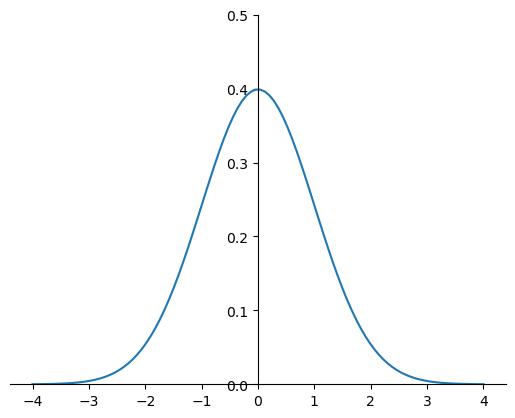

In [17]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-4, 4, 100)
ys = norm.pdf(xs)
plt.ylim(0, 0.5)
spines = plt.gca().spines
spines['left'].set_position('zero')
spines['right'].set_visible(False)
spines['top'].set_visible(False)
plt.plot(xs, ys)

キーワード引数 loc により平均値を指定できる。
loc は，location parameter の意であろう。

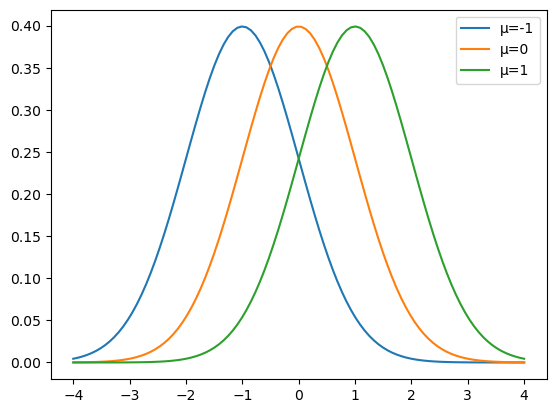

In [6]:
xs = np.linspace(-4, 4, 100)
ys1 = norm.pdf(xs, loc=-1.0)
ys2 = norm.pdf(xs, loc=0.0)
ys3 = norm.pdf(xs, loc=1.0)

plt.plot(xs, ys1, label = "μ=-1")
plt.plot(xs, ys2, label = "μ=0")
plt.plot(xs, ys3, label = "μ=1")
plt.legend()

キーワード引数 scale により標準偏差を指定できる（数学の教科書と異なり分散を指定するのではない）

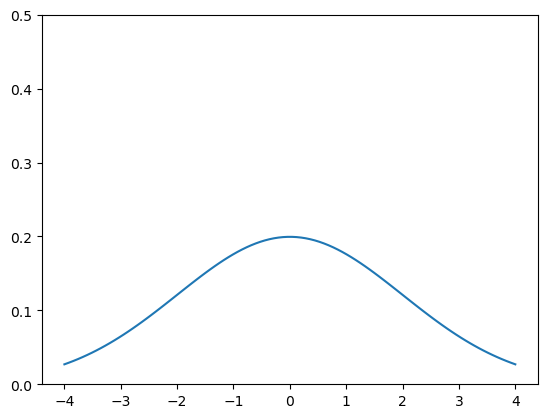

In [26]:
xs = np.linspace(-4, 4, 100)
ys = norm.pdf(xs, scale=2)
plt.ylim(0, 0.5)
plt.plot(xs, ys)

## 一様分布と三角分布

### 離散型一様分布
`randint(low, high)` で
`range(low, high)` の範囲の離散型一様分布が得られる。

<BarContainer object of 5 artists>

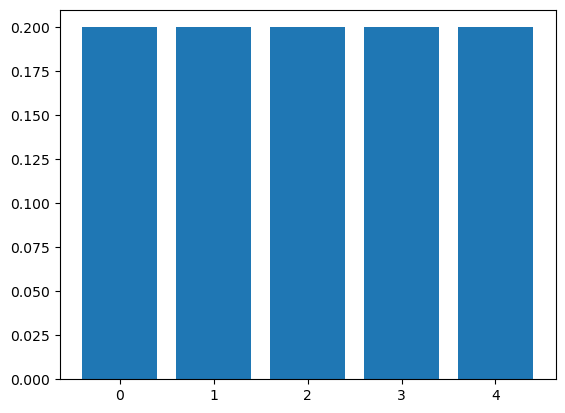

In [8]:
from scipy.stats import randint
import matplotlib.pyplot as plt

low = 0
high = 5
xs = [ x for x in range(low, high) ]
ys = randint.pmf(xs, low, high)
plt.bar(xs, ys)

`randint(low, high)` のモーメント統計量は次のとおり。
ただし $n$ はビンの個数すなわち high &minus; low

| 統計量 | 値 |
|-------|----|
| 平均値 | (low + high - 1)/2 |
| 分散  | $(n^2 - 1)/12$ |
| 歪度 | 0 |


In [7]:
from scipy.stats import randint

mean, var, skew = randint(0, 5).stats(moments='mvs')
print('平均', mean)
print('分散', var)
print('歪度', skew)

平均 2.0
分散 2.0
歪度 0.0


`uniform(loc, scale)` で連続型の一様分布が得られる。
`loc` は最小値，`scale` は範囲の大きさである。
従って最大値は `loc` + `scale`

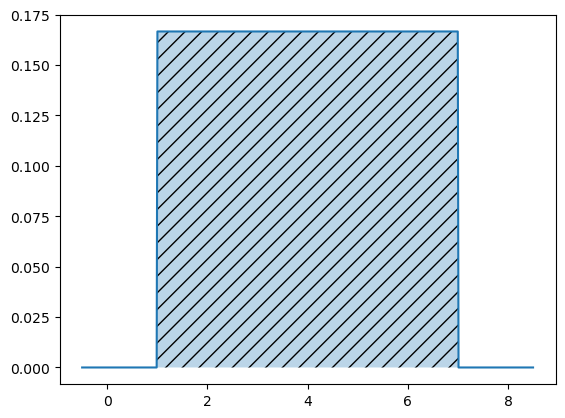

In [19]:
from scipy.stats import uniform
import numpy as np

left = 1
right = 7
dist = uniform(loc = left, scale = right - left)
xs = np.linspace(left-1.5, right+1.5, 600)
ys = dist.pdf(xs)
plt.fill_between(xs, ys, 0, alpha = 0.3, hatch = '//')
plt.plot(xs, ys)

`uniform(loc, scale)` のモーメント統計量は次のとおり。


| 統計量 | 値 |
|-------|----|
| 平均値 | loc + scale / 2 |
| 分散  | scale<sup>2</sup>/12 |
| 歪度 | 0 |
| 尖度 | &minus;6/5 |


In [21]:
from scipy.stats import uniform

uniform(loc = 1, scale = 6).stats(moments='mvsk')

(4.0, 3.0, 0.0, -1.2)

In [25]:
uniform.ppf([0/4, 1/4, 2/4, 3/4, 4/4], loc=0, scale=6)

array([0. , 1.5, 3. , 4.5, 6. ])

### 三角分布

2つの一様分布の和は**三角分布**というものになる。
正確には
>（独立に）一様分布に従う 2つの確率変数 $X$, $Y$ の和 $X+Y$ は
> 三角分布に従う。

<!-- いわゆる独立同一分布 (iid &mdash; independent and ideintically distributed) より条件が緩い。$X$, $Y$ の確率分布が異なる場合，（$X + Y$ の確率密度関数は）左右非対称になる。 -->

にわかにピンとくる命題ではないが，
手がかりさえつかめれば難しい話ではない。
2つの6面サイコロを振ったときのサイコロの目の合計について，事象を列挙してみよう。

In [6]:
import pandas as pd

freq = pd.DataFrame(0,
                    columns = [ i + 1 for i in range(6)],
                    index   = [ i + 1 for i in range(6)])
for i in freq.columns:
    for j in freq.index:
        freq.loc[i, j] = i + j

display(freq)

,1,2,3,4,5,6
1,2,3,4,5,6,7
2,3,4,5,6,7,8
3,4,5,6,7,8,9
4,5,6,7,8,9,10
5,6,7,8,9,10,11
6,7,8,9,10,11,12


サイコロを振ってどの目になるかは一様分布になるであろうから，サイコロの目の合計に着目して事象を数え上げれば，その分布がわかる。

<BarContainer object of 11 artists>

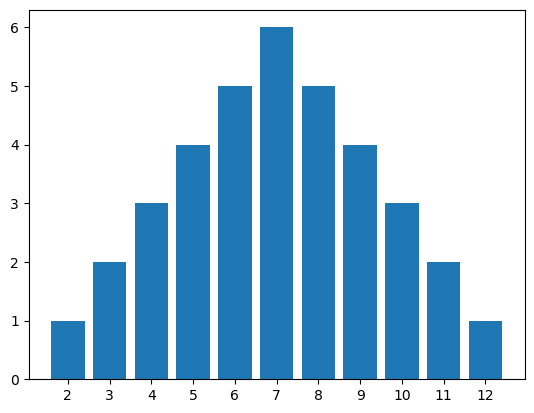

In [47]:
# 前のセルを実行していることが前提
# 変数 freq の値を定めておかないといけない

import numpy as np

# freq が全事象なので，その度数分布表を作る
hist = np.histogram([mat[i][j] for i in mat.columns
                               for j in mat.index],
                    11    # = len([2, 3, ..., 12])
                   )

# 集計表を棒グラフにする
import matplotlib.pyplot as plt
ys = hist[0]
xs = range(len(ys))
plt.bar(xs, ys, tick_label = [x + 2 for x in xs])

このように三角形の分布になる。
連続一様分布の和であれば，三角分布 `triang` で得られる。

`triang(c, loc, scale)` は，
左端が `loc`, 底辺の長さが `scale`, 
頂点の位置が `scale` のどの割合かを示す `c` で定まる三角分布である。
$$
0.0 < c < 1.0
$$
`loc` と `scale` のデフォルト値は，それぞれ 0.0 と 1.0 である。

たとえば `triang(0.5, loc = 0, scale = 2)` は，
独立に `uniform(0, 1)` に従う 2つの確率変数の和の確率分布である。

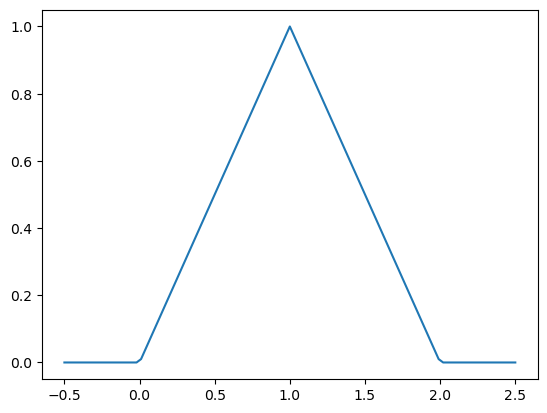

In [1]:
from scipy.stats import triang
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-0.5, 2.5, 101)
ys = triang.pdf(xs, c=0.5, loc = 0, scale = 2)
plt.plot(xs, ys)

三角分布は単純な仕組みの確率分布であり簡単に作れる。性質もわかりやすいので，単峰かつ $X$ の範囲が有限な確率分布の例として有用である。